# Lab 1: Crop Yield Prediction with Regularization

**Zhan Tabuldinov, BDA-2401**

The recommended topic was house prices, but the task allows another regression problem related to the major. I chose **crop yield prediction**: predict how many tonnes of a crop one hectare gives in a given country and year. It is a regression problem (the target is a continuous number) and it is important for Kazakhstan, where agriculture and wheat export are a big part of the economy.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sns.set_theme(style="whitegrid")

## 1. Dataset Selection

**Dataset:** Crop Yield Prediction Dataset (Kaggle, author Rishi Patel)
**Link:** https://www.kaggle.com/datasets/patelris/crop-yield-prediction-dataset
**Source of data:** FAO (yield, pesticides) and World Bank (rainfall, temperature).

**Why it is relevant to my major (Big Data Analytics):** the file is a join of four public datasets, and data integration and quality checks are a normal part of an analyst's work. Yield forecasts are used by the Ministry of Agriculture, grain traders and insurance companies in Kazakhstan.

* **Target:** `hg/ha_yield` – yield in hectograms per hectare (10 000 hg/ha = 1 t/ha).
* **Features:** `Area` (country), `Item` (crop), `Year`, `average_rain_fall_mm_per_year`, `pesticides_tonnes`, `avg_temp`.
* **Observations:** 28 242 rows, 6 features + target (+ one useless index column `Unnamed: 0`).

In [2]:
import kagglehub
path = kagglehub.dataset_download("patelris/crop-yield-prediction-dataset")
df = pd.read_csv(path + "/yield_df.csv")
print(df.shape)
df.head()

(28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


## 2. Business Understanding

* **What do we predict?** The yield of a crop (t/ha) in a country in a given year.
* **What decision does it support?** What to plant, how much harvest to expect, how to price crop insurance, how much grain to store or export.
* **Who will use it?** Analysts in the Ministry of Agriculture, agro-holdings, grain traders and insurers.
* **How does it help?** Today forecasts are made by hand from old averages. The model gives a fast and repeatable forecast for any country and crop and shows which factors matter (rain, temperature, pesticides, technology trend).
* **What makes it useful?** The error must be small compared to a normal year-to-year change of yield, and the model must be explainable.

**Success criteria (defined before modelling), measured on the test set:**

| Metric | Threshold | Reason |
|---|---|---|
| MAE | ≤ 2.0 t/ha | average yield is about 7 t/ha, median 4 t/ha; error of 2 t/ha is acceptable for planning |
| R² | ≥ 0.80 | the model must explain at least 80 % of the variation |

The main metric is **MAE** because it is in the same unit as the target and is easy to understand.

**Short glossary**

* *Regression* – predicting a continuous number.
* *MAE* – mean absolute error, average |actual − predicted|. *MSE* – mean squared error. *RMSE* – square root of MSE, punishes big errors more. *R²* – share of variance explained by the model (1 is perfect, 0 is the same as predicting the mean).
* *Regularization* – adding a penalty for big coefficients to reduce overfitting. *Ridge* uses L2 penalty (sum of squares), *Lasso* uses L1 penalty (sum of absolute values) and can set coefficients exactly to zero. *Alpha (α)* is the strength of the penalty.
* *Overfitting* – the model learns the training data too well and works worse on new data.
* *One-hot encoding* – turning a category into 0/1 columns. *Scaling* – bringing numeric features to the same scale (mean 0, std 1).
* *Data leakage* – using information from the test set during training.

## 3. Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,28242.0,14120.500000,8152.907488,0.00,7060.2500,14120.50,21180.75,28241.00
Year,28242.0,2001.544296,7.051905,1990.00,1995.0000,2001.00,2008.00,2013.00
hg/ha_yield,28242.0,77053.332094,84956.612897,50.00,19919.2500,38295.00,104676.75,501412.00
average_rain_fall_mm_per_year,28242.0,1149.055980,709.812150,51.00,593.0000,1083.00,1668.00,3240.00
pesticides_tonnes,28242.0,37076.909344,59958.784665,0.04,1702.0000,17529.44,48687.88,367778.00
avg_temp,28242.0,20.542627,6.312051,1.30,16.7025,21.51,26.00,30.65


The data has 28 242 rows and 8 columns, no missing values. Types are correct: `Area` and `Item` are text (categories), the rest are numbers. `Unnamed: 0` is just a row index.

The target is very skewed: mean 77 000 hg/ha but median 38 000, maximum 501 000. Pesticides are also very skewed (from 0.04 to 368 000 tonnes) because it is a total for the whole country. Temperature (1–31 °C) and rainfall (51–3240 mm) look realistic.

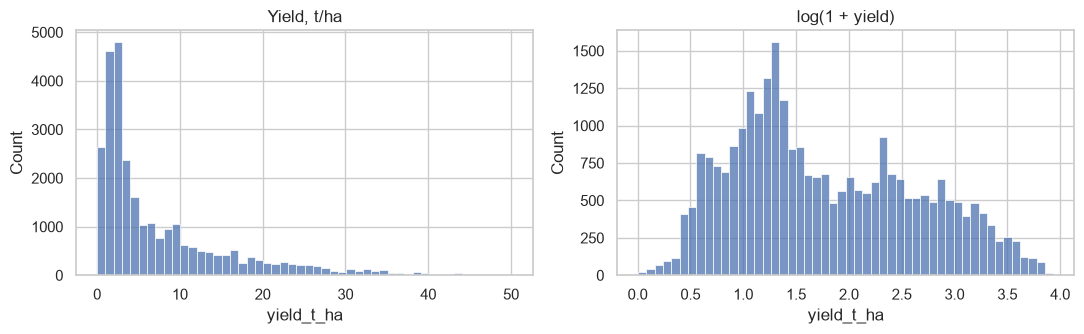

skew: 1.79 -> after log: 0.4


In [5]:
df["yield_t_ha"] = df["hg/ha_yield"] / 10000
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(df["yield_t_ha"], bins=50, ax=ax[0]).set(title="Yield, t/ha")
sns.histplot(np.log1p(df["yield_t_ha"]), bins=50, ax=ax[1]).set(title="log(1 + yield)")
plt.tight_layout(); plt.show()
print("skew:", round(df["yield_t_ha"].skew(), 2), "-> after log:", round(np.log1p(df["yield_t_ha"]).skew(), 2))

**Figure 1.** The target has a long right tail (skew 1.8). After a log transform it is almost symmetric (skew 0.4), so the linear models will be trained on log(yield) and predictions will be converted back to t/ha.

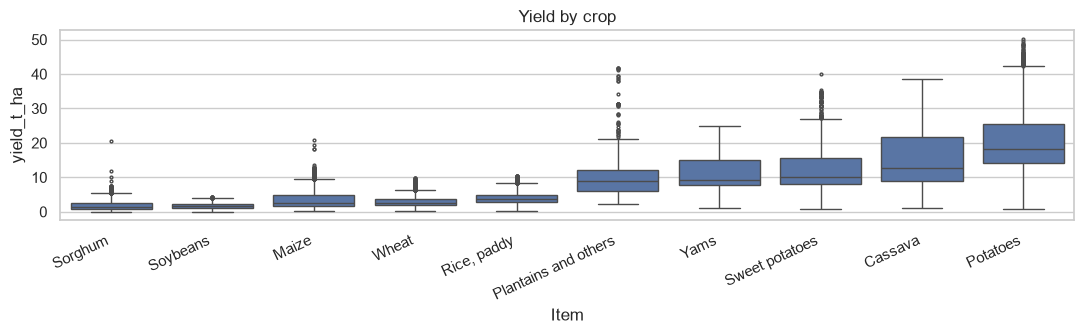

In [6]:
order = df.groupby("Item")["yield_t_ha"].median().sort_values().index
plt.figure(figsize=(11, 3.5))
sns.boxplot(data=df, x="Item", y="yield_t_ha", order=order, color="#4C72B0", fliersize=2)
plt.xticks(rotation=25, ha="right"); plt.title("Yield by crop"); plt.tight_layout(); plt.show()

**Figure 2.** The crop is the strongest factor. Root crops (potatoes, cassava, sweet potatoes, yams) give 10–20 t/ha, cereals (wheat, maize, rice, sorghum) and soybeans give only 1–4 t/ha. The spread inside one crop is still large – this is what the other features must explain.

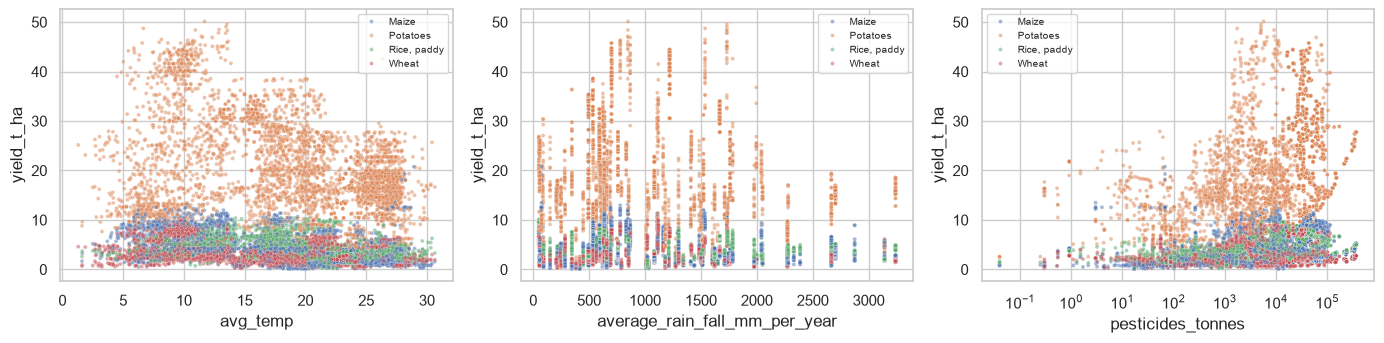

In [7]:
main = df[df["Item"].isin(["Wheat", "Maize", "Rice, paddy", "Potatoes"])]
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for a, col in zip(ax, ["avg_temp", "average_rain_fall_mm_per_year", "pesticides_tonnes"]):
    sns.scatterplot(data=main, x=col, y="yield_t_ha", hue="Item", s=8, alpha=0.5, ax=a)
    a.legend(fontsize=7)
ax[2].set_xscale("log")
plt.tight_layout(); plt.show()

**Figure 3.** Wheat and potatoes give the highest yield in cool countries (5–15 °C) and lower yield in hot countries; maize and rice are less sensitive to heat. Rainfall has no clear linear effect. Pesticides (log axis) have a weak positive relation: more intensive agriculture gives higher yield. The relations are not straight lines, so a non-linear model can be useful.

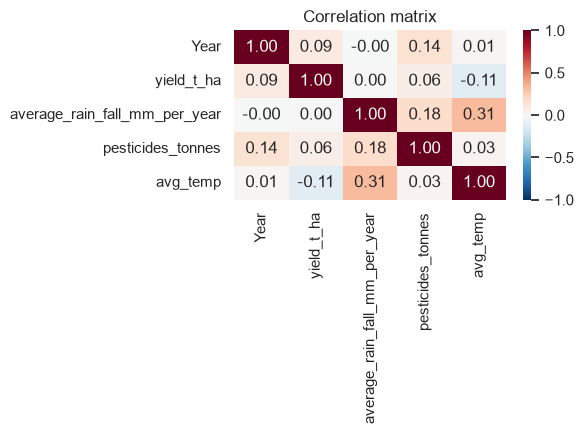

In [8]:
num = ["Year", "yield_t_ha", "average_rain_fall_mm_per_year", "pesticides_tonnes", "avg_temp"]
plt.figure(figsize=(6, 4.5))
sns.heatmap(df[num].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix"); plt.tight_layout(); plt.show()

**Figure 4.** No numeric feature has a strong linear correlation with yield (the biggest is temperature, −0.11). This is normal: the main structure is in the categories (crop and country). The numeric features are not correlated with each other (all |r| ≤ 0.31), so there is no multicollinearity between them.

In [9]:
print("rows:", len(df), " unique (country, crop, year):", len(df.drop_duplicates(["Area", "Item", "Year"])))
print("rainfall values per country (max):", df.groupby("Area")["average_rain_fall_mm_per_year"].nunique().max())
print("years:", sorted(df["Year"].unique().tolist()))
df[(df["Area"] == "India") & (df["Item"] == "Wheat") & (df["Year"] == 2000)].head(4)

rows: 28242  unique (country, crop, year): 13130
rainfall values per country (max): 1
years: [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013]


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,yield_t_ha
12416,12416,India,Wheat,2000,27785,1083.0,44957.52,25.98,2.7785
12417,12417,India,Wheat,2000,27785,1083.0,44957.52,27.44,2.7785
12418,12418,India,Wheat,2000,27785,1083.0,44957.52,26.13,2.7785
12419,12419,India,Wheat,2000,27785,1083.0,44957.52,24.57,2.7785


**Important patterns.** One row should be one country-crop-year, but 28 242 rows contain only 13 130 unique combinations. The reason: the temperature file had several records per country and year (different cities), and the join copied every yield row for each of them – the yield is the same, only the temperature is a bit different. Also rainfall is a constant per country (it is not a yearly value), and the year 2003 is missing.

## 4. Data Cleaning

Checks: missing values, duplicates, data types, impossible values, outliers, category names.

In [10]:
df = df.drop(columns=["Unnamed: 0"])
print("missing values:", df.isna().sum().sum())
print("exact duplicates:", df.duplicated().sum())
before = len(df)
df = df.drop_duplicates()
print("rows before:", before, "-> after:", len(df))

missing values: 0
exact duplicates: 2310
rows before: 28242 -> after: 25932


In [11]:
before = len(df)
df = df.groupby(["Area", "Item", "Year"], as_index=False).agg({"hg/ha_yield": "first", "yield_t_ha": "first",
        "average_rain_fall_mm_per_year": "first", "pesticides_tonnes": "first", "avg_temp": "mean"})
print("rows before:", before, "-> after (one row per country-crop-year):", len(df))

rows before: 25932 -> after (one row per country-crop-year): 13130


**Duplicates: before → after.** 28 242 → 25 932 rows after removing 2 310 exact duplicates → **13 130 rows** after keeping one row per country-crop-year (temperature is averaged, other values were identical). Without this step the same observation would be in both train and test set (data leakage).

In [12]:
print((df["yield_t_ha"] <= 0).sum(), (df["average_rain_fall_mm_per_year"] <= 0).sum(),
      (df["pesticides_tonnes"] < 0).sum(), (~df["avg_temp"].between(-20, 40)).sum())
df.nsmallest(3, "yield_t_ha")

0 0 0 0


,Area,Item,Year,hg/ha_yield,yield_t_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
11826,Tajikistan,Soybeans,1992,50,0.005,691.0,2280.0,7.90
11827,Tajikistan,Soybeans,1993,80,0.008,691.0,2280.0,7.29
11837,Tajikistan,Soybeans,2004,100,0.010,691.0,228.5,9.24


**Impossible values:** none (no zero or negative yield, rain or pesticides, temperature is realistic). The smallest yields (0.005 t/ha) are soybeans in Tajikistan in the 1990s – a real FAO record, so I keep them.

In [13]:
q1, q3 = df["yield_t_ha"].quantile([0.25, 0.75])
out = ((df["yield_t_ha"] < q1 - 1.5 * (q3 - q1)) | (df["yield_t_ha"] > q3 + 1.5 * (q3 - q1))).sum()
print("IQR outliers in yield:", out, f"({out / len(df):.1%})")
print(df["Item"].unique())
print(df["Area"].nunique(), "countries, spaces in names:", (df["Area"] != df["Area"].str.strip()).sum())

IQR outliers in yield: 814 (6.2%)
['Maize' 'Potatoes' 'Rice, paddy' 'Sorghum' 'Soybeans' 'Wheat' 'Cassava'
 'Sweet potatoes' 'Plantains and others' 'Yams']
101 countries, spaces in names: 0


**Outliers:** 814 rows (6 %) are IQR outliers, but they are real high-yield potato fields, not errors. I keep them and use the log transform of the target instead of deleting data.
**Categories:** 10 crop names and 101 country names are consistent (no extra spaces, no duplicates with different spelling).

## 5. Feature Engineering

| Action | Feature | Why |
|---|---|---|
| Removed | `Unnamed: 0` | row index, no information |
| Removed | `hg/ha_yield` | replaced by `yield_t_ha` (tonnes per hectare, the unit used in agriculture) |
| Removed | `pesticides_tonnes` | replaced by its log |
| Removed | `avg_temp` | it is "country climate + this year's anomaly"; the climate part is already in the country dummies, so together with the new feature it would be a duplicate |
| Created | `log_pesticides` = log(1 + pesticides) | the first tonnes of pesticides matter more than the millionth (diminishing returns); removes the skew |
| Created | `temp_anomaly` = temperature − average temperature of the country | shows if the year was hotter or colder than normal for this country – a "weather shock" feature |
| Kept | `Year` | technology improves over time, yield grows |
| Kept | `Area`, `Item` | strongest factors, will be one-hot encoded |

In [14]:
df["log_pesticides"] = np.log1p(df["pesticides_tonnes"])
df["temp_anomaly"] = df["avg_temp"] - df.groupby("Area")["avg_temp"].transform("mean")
df = df.drop(columns=["hg/ha_yield", "pesticides_tonnes", "avg_temp"]).rename(columns={"average_rain_fall_mm_per_year": "rainfall_mm"})
print("pesticides skew after log:", round(df["log_pesticides"].skew(), 2))
df.head()

pesticides skew after log: -0.39


,Area,Item,Year,yield_t_ha,rainfall_mm,log_pesticides,temp_anomaly
0,Albania,Maize,1990,3.6613,1485.0,4.804021,0.069899
1,Albania,Maize,1991,2.9068,1485.0,4.804021,-0.940101
2,Albania,Maize,1992,2.4876,1485.0,4.804021,-0.240101
3,Albania,Maize,1993,2.4185,1485.0,4.804021,-0.250101
4,Albania,Maize,1994,2.5848,1485.0,5.308268,0.659899


## 6. Data Preprocessing

* X and y are separated, split 80 / 20 with `random_state=42`.
* `Area` and `Item` → OneHotEncoder, numeric features → StandardScaler (needed for Ridge and Lasso, so that the penalty is fair for all features).
* Everything is inside a `Pipeline` with a `ColumnTransformer`, so scaling and encoding are fitted on the training data only – no leakage.
* The target is log-transformed inside `TransformedTargetRegressor`; predictions are automatically converted back to t/ha.

In [15]:
X = df.drop(columns=["yield_t_ha"])
y = df["yield_t_ha"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
num_cols = ["Year", "rainfall_mm", "log_pesticides", "temp_anomaly"]
cat_cols = ["Area", "Item"]
prep = ColumnTransformer([("num", StandardScaler(), num_cols), ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])

def make(model):
    return Pipeline([("prep", prep), ("model", TransformedTargetRegressor(model, func=np.log1p, inverse_func=np.expm1))])

print(X_train.shape, X_test.shape)

(10504, 6) (2626, 6)


## 7. Training

All models use the same pipeline. Alpha for Ridge and Lasso and the depth of the tree are chosen by 5-fold cross-validation on the training set (metric: MAE).

In [16]:
results = {}
def evaluate(name, pipe):
    p = pipe.predict(X_test)
    results[name] = [mean_absolute_error(y_test, p), mean_squared_error(y_test, p), np.sqrt(mean_squared_error(y_test, p)), r2_score(y_test, p)]
    print(name, "MAE = %.3f  R2 = %.3f" % (results[name][0], results[name][3]))

**Linear Regression** – the baseline. It is simple and explainable: on the log scale, yield = crop effect × country effect × trend. Its weakness is that it cannot learn interactions (for example, that temperature works differently for wheat and for maize).

In [17]:
lr = make(LinearRegression()).fit(X_train, y_train)
evaluate("Linear Regression", lr)
print("train R2 = %.3f" % r2_score(y_train, lr.predict(X_train)))

Linear Regression MAE = 2.044  R2 = 0.812


train R2 = 0.803


**Ridge (L2).** The penalty α·Σw² makes all coefficients smaller. Small α = almost the same as linear regression, big α = coefficients go to zero and the model underfits. Ridge is useful when features are correlated (here rainfall is a constant per country, so it is a copy of the country dummies).

best alpha: 0.001
Ridge MAE = 2.044  R2 = 0.812


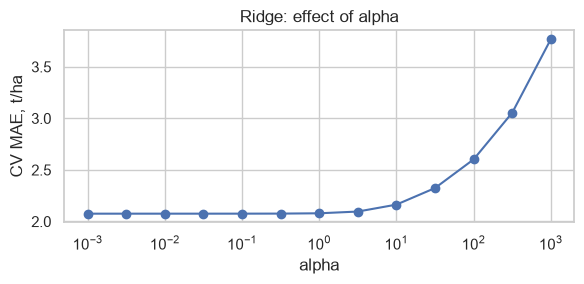

In [18]:
alphas = np.logspace(-3, 3, 13)
ridge = GridSearchCV(make(Ridge()), {"model__regressor__alpha": alphas}, cv=5, scoring="neg_mean_absolute_error").fit(X_train, y_train)
print("best alpha:", ridge.best_params_["model__regressor__alpha"])
evaluate("Ridge", ridge.best_estimator_)
plt.figure(figsize=(6, 3))
plt.semilogx(alphas, -ridge.cv_results_["mean_test_score"], marker="o")
plt.xlabel("alpha"); plt.ylabel("CV MAE, t/ha"); plt.title("Ridge: effect of alpha"); plt.tight_layout(); plt.show()

**Figure 5.** For α ≤ 1 the error does not change – the penalty is too small to matter. From α ≈ 10 the error grows fast because the coefficients are shrunk too much (underfitting). The best α is the smallest one, so regularization does not help accuracy here.

**Lasso (L1).** The penalty α·Σ|w| can make coefficients exactly zero, so Lasso does feature selection automatically. With 111 one-hot columns this can show which countries and crops really need their own coefficient.

best alpha: 0.0001
Lasso MAE = 2.046  R2 = 0.812


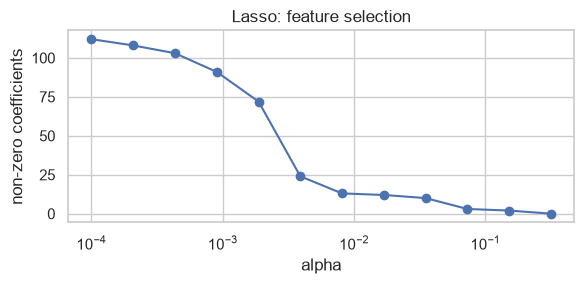

In [19]:
alphas = np.logspace(-4, -0.5, 12)
lasso = GridSearchCV(make(Lasso(max_iter=50000)), {"model__regressor__alpha": alphas}, cv=5, scoring="neg_mean_absolute_error").fit(X_train, y_train)
print("best alpha:", lasso.best_params_["model__regressor__alpha"])
evaluate("Lasso", lasso.best_estimator_)
nonzero = [(make(Lasso(alpha=a, max_iter=50000)).fit(X_train, y_train).named_steps["model"].regressor_.coef_ != 0).sum() for a in alphas]
plt.figure(figsize=(6, 3))
plt.semilogx(alphas, nonzero, marker="o")
plt.xlabel("alpha"); plt.ylabel("non-zero coefficients"); plt.title("Lasso: feature selection"); plt.tight_layout(); plt.show()

**Figure 6.** When α grows, Lasso switches off features one by one: from 108 non-zero coefficients (of 115) at α = 0.0001 to about 29 at α = 0.004 and 0 at α = 0.3. But every removed country dummy makes the error bigger, so the best α is again the smallest one.

**Decision Tree** – a non-linear baseline. It splits the data step by step (first by crop, then by country or climate) and can learn interactions that linear models cannot. The risk is overfitting, so depth and minimum leaf size are tuned by cross-validation.

In [20]:
grid = {"model__regressor__max_depth": [6, 10, 14, 18, None], "model__regressor__min_samples_leaf": [1, 3, 5, 10, 20]}
tree = GridSearchCV(make(DecisionTreeRegressor(random_state=42)), grid, cv=5, scoring="neg_mean_absolute_error").fit(X_train, y_train)
print("best params:", tree.best_params_)
evaluate("Decision Tree", tree.best_estimator_)
print("train R2 = %.3f" % r2_score(y_train, tree.best_estimator_.predict(X_train)))

best params: {'model__regressor__max_depth': None, 'model__regressor__min_samples_leaf': 1}
Decision Tree MAE = 0.799  R2 = 0.957
train R2 = 1.000


## 8. Evaluation

In [21]:
res = pd.DataFrame(results, index=["MAE", "MSE", "RMSE", "R2"]).T.sort_values("MAE")
res["MAE <= 2.0"] = res["MAE"] <= 2.0
res["R2 >= 0.80"] = res["R2"] >= 0.80
res.round(3)

,MAE,MSE,RMSE,R2,MAE <= 2.0,R2 >= 0.80
Decision Tree,0.799,2.795,1.672,0.957,True,True
Ridge,2.044,12.069,3.474,0.812,False,True
Linear Regression,2.044,12.071,3.474,0.812,False,True
Lasso,2.046,12.069,3.474,0.812,False,True


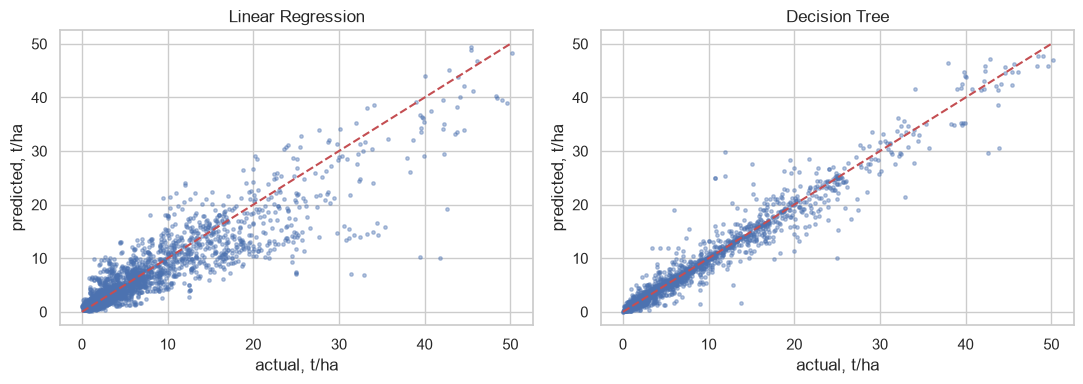

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, name, pipe in zip(ax, ["Linear Regression", "Decision Tree"], [lr, tree.best_estimator_]):
    p = pipe.predict(X_test)
    a.scatter(y_test, p, s=6, alpha=0.4)
    a.plot([0, 50], [0, 50], "r--")
    a.set(xlabel="actual, t/ha", ylabel="predicted, t/ha", title=name)
plt.tight_layout(); plt.show()

In [23]:
names = lasso.best_estimator_.named_steps["prep"].get_feature_names_out()
coef = pd.Series(lasso.best_estimator_.named_steps["model"].regressor_.coef_, index=names)
print("Lasso set to zero:", list(coef[coef == 0].index))
print(coef[["num__Year", "num__rainfall_mm", "num__log_pesticides", "num__temp_anomaly"]].round(3))
print("Top 5 positive:", coef.nlargest(5).round(2).to_dict())
print("Top 5 negative:", coef.nsmallest(5).round(2).to_dict())

Lasso set to zero: ['cat__Area_Belarus', 'cat__Area_Colombia', 'cat__Area_Estonia']
num__Year              0.071
num__rainfall_mm      -0.029
num__log_pesticides    0.055
num__temp_anomaly      0.000
dtype: float64
Top 5 positive: {'cat__Item_Potatoes': 1.13, 'cat__Area_Belgium': 0.98, 'cat__Item_Yams': 0.96, 'cat__Item_Plantains and others': 0.96, 'cat__Area_Netherlands': 0.94}
Top 5 negative: {'cat__Item_Soybeans': -0.74, 'cat__Area_Eritrea': -0.73, 'cat__Area_Central African Republic': -0.73, 'cat__Area_Mauritania': -0.62, 'cat__Item_Sorghum': -0.6}


**Which model performed best?** The **Decision Tree**: MAE = 0.80 t/ha and R² = 0.957. The three linear models are almost equal to each other: MAE ≈ 2.04 t/ha, R² = 0.812. The tree wins because it learns interactions between crop, country and climate, which an additive linear model cannot do (Figure 3).

**Which metric was most important?** MAE in t/ha – it is the average planning error in the unit that farmers and traders use, and it is less sensitive to a few very high potato yields than MSE/RMSE. R² is the second criterion.

**Did regularization improve Linear Regression?** No. Ridge and Lasso give the same test error as the baseline (difference < 0.01 t/ha), and cross-validation chose the smallest α in both grids. The reason: with 10 500 training rows and 115 features linear regression does not overfit (train R² = 0.80 ≈ test R² = 0.81), so there is no variance to reduce. The problem of the linear model is bias (missing interactions), and regularization cannot fix that.

**Did Lasso remove or reduce the importance of some features?** Yes, a little. At the best α it set 3 country dummies to zero (Belarus, Colombia, Estonia – countries that are not different from the average) and `temp_anomaly` is also zero, so the "weather shock" feature turned out useless. The sum of |coefficients| is about 10 % smaller than in OLS. With bigger α Lasso removes many more features (Figure 6), but the error grows.

**Did the best model meet the success criteria?** Yes. The Decision Tree has MAE = 0.80 ≤ 2.0 and R² = 0.957 ≥ 0.80. The linear models pass the R² criterion (0.81) but miss the MAE threshold a little (2.04 > 2.0). One note: the best tree is fully grown (train R² = 1.0), it "remembers" the training data; it still works on the test set because neighbouring years of the same country and crop are very similar.

## 9. Conclusion

* **Data:** Kaggle crop yield dataset (FAO / World Bank), 101 countries, 10 crops, 1990–2013.
* **EDA:** the target is skewed and depends mostly on the crop type; numeric features have weak linear correlation with yield; rainfall is a constant per country; year 2003 is missing.
* **Cleaning:** no missing values; 2 310 exact duplicates removed; rows that were copied by the temperature join were collapsed to one row per country-crop-year (28 242 → 13 130). Real extreme values were kept, no impossible values found.
* **Features:** target converted to t/ha and log-transformed for training; created `log_pesticides` (useful) and `temp_anomaly` (turned out useless); removed the index column and `avg_temp`.
* **Models:** Linear Regression, Ridge, Lasso (α by cross-validation) and Decision Tree. Best model – Decision Tree, MAE = 0.80 t/ha, R² = 0.957. Linear models: MAE ≈ 2.04, R² = 0.81. Regularization did not improve accuracy because the linear model does not overfit.
* **Business criteria:** met by the Decision Tree; the linear models miss the MAE threshold slightly.
* **Limitations:** pesticides and rainfall are country totals, not field data; rainfall does not change by year, so the model cannot see a dry year; data ends in 2013; a random split lets the model see other years of the same country and crop, so real next-year forecasts will be less accurate; a single deep tree is unstable.
* **Next steps:** (1) use Random Forest or Gradient Boosting with a time-based validation (train on old years, test on new years); (2) add interaction features (crop × temperature) to the linear model; (3) add yearly rainfall, soil and fertilizer data from FAOSTAT and regional data for Kazakhstan.

## 10. References

1. Patel R. *Crop Yield Prediction Dataset*. Kaggle. https://www.kaggle.com/datasets/patelris/crop-yield-prediction-dataset
2. FAO. *FAOSTAT*. https://www.fao.org/faostat/
3. World Bank. *Climate Change Knowledge Portal*. https://data.worldbank.org/
4. Google Developers. *Introduction to ML Problem Framing*. https://developers.google.com/machine-learning/problem-framing
5. Scikit-learn documentation: LinearRegression, Ridge, Lasso, DecisionTreeRegressor, Pipeline, ColumnTransformer. https://scikit-learn.org/stable/
6. James G., Witten D., Hastie T., Tibshirani R. *An Introduction to Statistical Learning*, 2nd ed., ch. 3 and 6. https://www.statlearning.com/
7. Tibshirani R. (1996). Regression Shrinkage and Selection via the Lasso. *JRSS B*, 58(1).
8. Hoerl A., Kennard R. (1970). Ridge Regression: Biased Estimation for Nonorthogonal Problems. *Technometrics*, 12(1).